# Data Profiling – Mobile Legends Play Store Dataset

Notebook ini digunakan untuk profiling awal dataset `mobilelegends.csv`.

Dataset berada di:
`data/raw/archive/mobilelegends.csv`

> Karena file CSV berukuran sekitar 3 GB, notebook menggunakan **chunking** agar tidak perlu memuat seluruh dataset ke RAM sekaligus.


## Struktur Dataset

Berdasarkan dataset yang kamu tunjukkan, kolomnya adalah:

| Kolom | Keterangan |
|---|---|
| `reviewId` | ID review |
| `userName` | Nama pengguna |
| `userImage` | URL gambar pengguna |
| `content` | Isi review |
| `score` | Rating review (1–5) |
| `thumbsUpCount` | Jumlah thumbs up |
| `reviewCreatedVersion` | Versi game saat review dibuat |
| `at` | Waktu/tanggal review |
| `replyContent` | Isi balasan pengembang |
| `repliedAt` | Waktu/tanggal balasan pengembang |

Unit analisis: **satu review pengguna Mobile Legends di Google Play Store**.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/archive/mobilelegends.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"File tidak ditemukan: {DATA_PATH}. "
        "Pastikan notebook berada di folder notebooks/."
    )

file_size_gb = os.path.getsize(DATA_PATH) / (1024**3)
print(f"Lokasi dataset : {DATA_PATH}")
print(f"Ukuran file    : {file_size_gb:.2f} GB")


Lokasi dataset : ../data/raw/archive/mobilelegends.csv
Ukuran file    : 2.88 GB


## 1. Preview Data

In [2]:
preview = pd.read_csv(DATA_PATH, nrows=5)

print("Jumlah kolom:", len(preview.columns))
print("\nNama kolom:")
for i, col in enumerate(preview.columns, 1):
    print(f"{i}. {col}")

display(preview)


Jumlah kolom: 11

Nama kolom:
1. reviewId
2. userName
3. userImage
4. content
5. score
6. thumbsUpCount
7. reviewCreatedVersion
8. at
9. replyContent
10. repliedAt
11. appVersion


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9132a8ef-cf00-4812-836a-8a6b86372d69,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"WOEE MONTOONN KASII GUA WS, CAPEE BANGET NAIK ...",1,0,2.2.16.12322,2026-09-27 07:20:57,NaN,NaN,2.2.16.12322
1,55eccf21-3a36-49ff-89e7-73ff6a11b05e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bagus,5,0,2.2.16.12322,2026-09-27 07:20:27,NaN,NaN,2.2.16.12322
2,21e33d47-dd1f-49ba-8bd1-03aea8237ef3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat baik,4,0,2.2.16.12322,2026-09-27 07:20:14,NaN,NaN,2.2.16.12322
3,57f89308-7935-435e-ae53-c2a93281d916,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus sih tapi cuma itu selalu ke pencet sendi...,4,0,2.2.16.12322,2026-09-27 07:18:11,NaN,NaN,2.2.16.12322
4,e4a2bed7-4f62-4825-8c74-64935fb4eb20,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,main solo history aja menang kalah eh akun mal...,1,0,2.2.16.12322,2026-09-27 07:18:09,NaN,NaN,2.2.16.12322


## 2. Tipe Data

In [3]:
display(preview.dtypes.to_frame("dtype"))


,dtype
reviewId,str
userName,str
userImage,str
content,str
score,int64
thumbsUpCount,int64
reviewCreatedVersion,str
at,str
replyContent,float64
repliedAt,float64


## 3. Profiling Seluruh Dataset

Dataset diproses menggunakan `chunksize=50_000`.

Profiling mencakup:
- jumlah baris;
- missing values;
- `reviewId` unik dan duplikat;
- distribusi `score`;
- jumlah review yang memiliki balasan pengembang.


In [4]:
CHUNK_SIZE = 50_000

row_count = 0
missing_counts = pd.Series(0, index=preview.columns, dtype="int64")
score_counts = pd.Series(dtype="int64")
unique_review_ids = set()
duplicate_review_ids = 0
replied_count = 0

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    row_count += len(chunk)
    missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0)

    if "reviewId" in chunk.columns:
        for review_id in chunk["reviewId"].dropna():
            if review_id in unique_review_ids:
                duplicate_review_ids += 1
            else:
                unique_review_ids.add(review_id)

    if "score" in chunk.columns:
        score_counts = score_counts.add(chunk["score"].value_counts(), fill_value=0)

    if "replyContent" in chunk.columns:
        replied_count += chunk["replyContent"].notna().sum()

print(f"Total baris: {row_count:,}")
print(f"Total kolom: {len(preview.columns)}")
print(f"Review ID unik: {len(unique_review_ids):,}")
print(f"Review ID duplikat: {duplicate_review_ids:,}")
print(f"Review dengan balasan pengembang: {replied_count:,}")


Total baris: 10,448,859
Total kolom: 11
Review ID unik: 10,448,859
Review ID duplikat: 0
Review dengan balasan pengembang: 138,739


## 4. Missing Values

In [5]:
missing_table = pd.DataFrame({
    "column": missing_counts.index,
    "missing_count": missing_counts.astype(int).values,
    "missing_percent": (missing_counts / row_count * 100).round(2).values
}).sort_values("missing_count", ascending=False)

display(missing_table)


,column,missing_count,missing_percent
9,repliedAt,10310120,98.67
8,replyContent,10310120,98.67
6,reviewCreatedVersion,3578132,34.24
10,appVersion,3578132,34.24
3,content,27,0.00
0,reviewId,0,0.00
1,userName,0,0.00
2,userImage,0,0.00
4,score,0,0.00
5,thumbsUpCount,0,0.00


## 5. Distribusi Rating

,score,count,percentage
0,0,6,0.00
1,1,2431640,23.27
2,2,401911,3.85
3,3,537955,5.15
4,4,767444,7.34
5,5,6309903,60.39


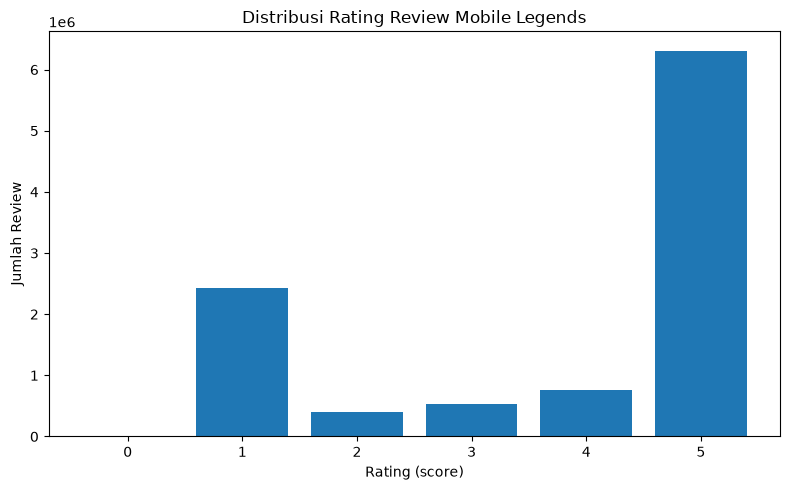

In [6]:
score_counts = score_counts.sort_index().astype(int)

score_table = pd.DataFrame({
    "score": score_counts.index.astype(int),
    "count": score_counts.values,
    "percentage": (score_counts.values / row_count * 100).round(2)
})

display(score_table)

plt.figure(figsize=(8, 5))
plt.bar(score_table["score"].astype(str), score_table["count"])
plt.xlabel("Rating (score)")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Rating Review Mobile Legends")
plt.tight_layout()
plt.show()


## 6. Statistik Deskriptif

In [7]:
numeric_frames = []

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=lambda c: c in ["score", "thumbsUpCount"],
    chunksize=CHUNK_SIZE
):
    numeric_frames.append(chunk)

numeric_data = pd.concat(numeric_frames, ignore_index=True)
display(numeric_data.describe().T)


,count,mean,std,min,25%,50%,75%,max
score,10448859.0,3.777314,1.689412,0.0,2.0,5.0,5.0,5.0
thumbsUpCount,10448859.0,1.052097,65.803979,0.0,0.0,0.0,0.0,43282.0


## 7. Periode Data

In [8]:
min_date = None
max_date = None

for chunk in pd.read_csv(DATA_PATH, usecols=["at"], chunksize=CHUNK_SIZE):
    dates = pd.to_datetime(chunk["at"], errors="coerce")
    chunk_min = dates.min()
    chunk_max = dates.max()

    if pd.notna(chunk_min):
        min_date = chunk_min if min_date is None else min(min_date, chunk_min)
    if pd.notna(chunk_max):
        max_date = chunk_max if max_date is None else max(max_date, chunk_max)

print("Tanggal review paling awal :", min_date)
print("Tanggal review paling akhir:", max_date)


Tanggal review paling awal : 2016-09-24 10:10:08
Tanggal review paling akhir: 2026-09-27 07:20:57


## 8. Kesimpulan Profiling

Setelah seluruh cell dijalankan, gunakan hasil di atas untuk menjelaskan:

1. ukuran dataset dan jumlah baris/kolom;
2. tipe data setiap kolom;
3. kondisi missing values;
4. potensi duplikasi berdasarkan `reviewId`;
5. distribusi rating `score`;
6. jumlah review yang memperoleh balasan pengembang; dan
7. periode waktu review.

Penggunaan `chunksize` menunjukkan bahwa dataset besar dapat diproses bertahap tanpa harus memuat seluruh file 3 GB ke memori.
